In [2]:
import numpy as np 
from matplotlib import pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import MaxNLocator
import pickle
import os

import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.gridspec as gridspec

# Plotting params

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 10,                    # Base font size
    "axes.labelsize": 18,              # Axis label font size
    "axes.labelweight": "bold",         # Bold axis labels
    "font.weight": "bold",          # Bold font for all text
    "axes.titlesize": 13,              # Axis title (not fig title)
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 18,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.figsize": (3.25, 2.6),     # For 0.5\textwidth plot
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

save_fig = True
# Check if folder already exists
# assert not os.path.exists(folder_name), f"AssertionError: Folder '{folder_name}' already exists!"


# Plotting

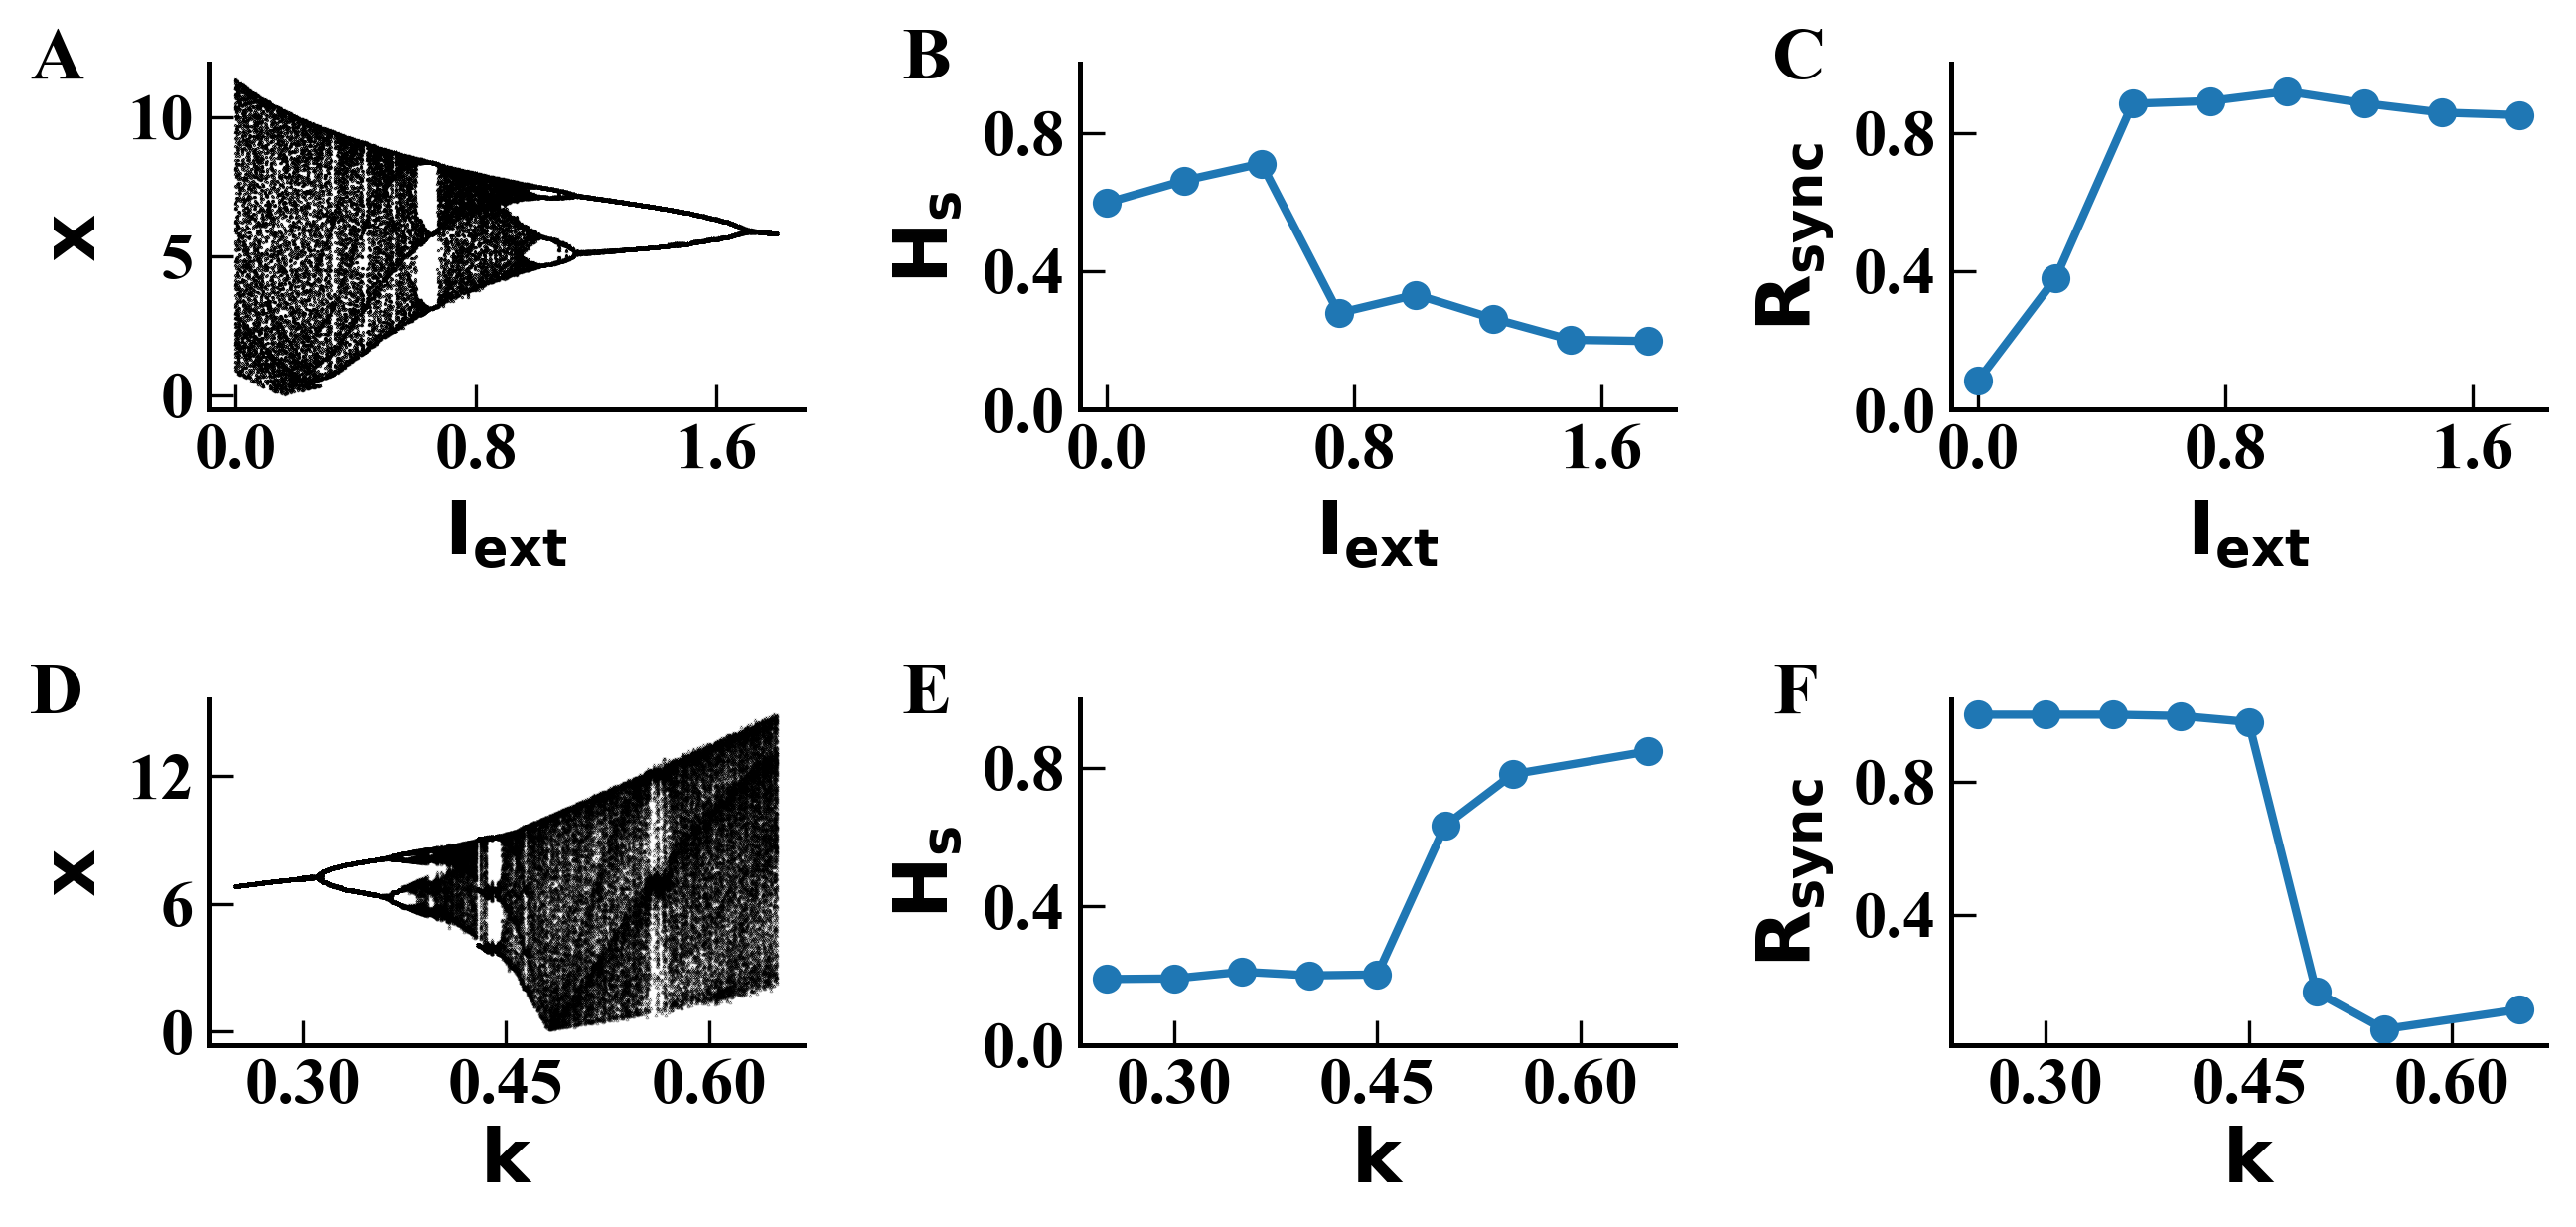

In [4]:
# ...existing code...
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pickle
import os

# Load data for I_ext plots
with open("DATA/I_ext_APC_Entropy_phase_sync.pkl", "rb") as file:
    data_Iext = pickle.load(file)
I_ext_arr = data_Iext['Iext']
phase_sync_Iext = data_Iext['PHASE_SYNC']
entropy_Iext = data_Iext['ENTROPY']

with open("data/I_ext_bifurcation.pkl", "rb") as file:
    bif_Iext = pickle.load(file)
I_ext_bif_arr = np.array(list(bif_Iext.keys()))

# Load data for k plots
with open("DATA/k_APC_Entropy_phase_sync.pkl", "rb") as file:
    data_k = pickle.load(file)
k_arr = data_k['k']
phase_sync_k = data_k['PHASE_SYNC']
entropy_k = data_k['ENTROPY']

with open("DATA/k_bifurcation.pkl", "rb") as file:
    bif_k = pickle.load(file)['bifurcation']
k_bif_arr = np.array(list(bif_k.keys()))

# Scientific plotting style
plt.rcParams.update({
    
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 18,
    "axes.labelsize": 22,
    "axes.labelweight": "bold",
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "font.weight": "bold", 
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
    "lines.markersize": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

fig, axs = plt.subplots(2, 3, figsize=(9, 4.5), constrained_layout= False,)

# Row 1: I_ext plots
axs[0, 2].plot(I_ext_arr, phase_sync_Iext, color='tab:blue', marker='o', linewidth=2, markersize = 6)
axs[0, 2].set_xlabel(r'$\mathbf{I_{ext}}$', fontsize=18, fontweight='bold')
axs[0, 2].set_ylabel(r'$\mathbf{R_{sync}}$', fontsize=18, fontweight='bold')
axs[0, 2].tick_params(axis='both', labelsize=16)
axs[0, 2].xaxis.set_major_locator(MaxNLocator(nbins=3))
axs[0, 2].yaxis.set_major_locator(MaxNLocator(nbins=3))
axs[0, 2].set_ylim([0, 1])
# axs[0, 2].set_title(r'$\mathbf{I_{ext}}$ vs $\mathbf{R_{sync}}$', fontsize=20, fontweight='bold')

axs[0, 1].plot(I_ext_arr, entropy_Iext, color='tab:blue', marker='o', linewidth=2, markersize = 6)
axs[0, 1].set_xlabel(r'$\mathbf{I_{ext}}$', fontsize=18, fontweight='bold')
axs[0, 1].set_ylabel(r'$\mathbf{H_{s}}$', fontsize=18, fontweight='bold')
axs[0, 1].tick_params(axis='both', labelsize=16)
axs[0, 1].xaxis.set_major_locator(MaxNLocator(nbins=3))
axs[0, 1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axs[0, 1].set_ylim([0, 1])
# axs[0, 1].set_title(r'$\mathbf{I_{ext}}$ vs $\mathbf{H_{s}}$', fontsize=20, fontweight='bold')

for I_ext in I_ext_bif_arr:
    x_peak_vals = bif_Iext[I_ext]
    x_ax = I_ext * np.ones(x_peak_vals.shape[0])
    axs[0, 0].plot(x_ax, x_peak_vals, '*', color='black', markersize=0.1)
axs[0, 0].set_xlabel(r'$\mathbf{I_{ext}}$', fontsize=18, fontweight='bold')
axs[0, 0].set_ylabel(r'$\mathbf{x}$', fontsize=18, fontweight='bold')
axs[0, 0].tick_params(axis='both', labelsize=16)
axs[0, 0].xaxis.set_major_locator(MaxNLocator(nbins=3))
axs[0, 0].yaxis.set_major_locator(MaxNLocator(nbins=3))
# axs[0, 2].set_title(r'$\mathbf{I_{ext}}$ Bifurcation', fontsize=20, fontweight='bold')

# Row 2: k plots
axs[1, 2].plot(k_arr, phase_sync_k, color='tab:blue', marker='o', linewidth=2, markersize = 6)
axs[1, 2].set_xlabel(r'$\mathbf{k}$', fontsize=18, fontweight='bold')
axs[1, 2].set_ylabel(r'$\mathbf{R_{sync}}$', fontsize=18, fontweight='bold')
axs[1, 2].tick_params(axis='both', labelsize=16)
axs[1, 2].xaxis.set_major_locator(MaxNLocator(nbins=3))
axs[1, 2].yaxis.set_major_locator(MaxNLocator(nbins=3))
# axs[1, 2].set_ylim([0, 1])
# axs[1, 0].set_title(r'$\mathbf{k}$ vs $\mathbf{\Phi_{sync}}$', fontsize=20, fontweight='bold')

axs[1, 1].plot(k_arr, entropy_k, color='tab:blue', marker='o', linewidth=2, markersize = 6)
axs[1, 1].set_xlabel(r'$\mathbf{k}$', fontsize=18, fontweight='bold')
axs[1, 1].set_ylabel(r'$\mathbf{H_{s}}$', fontsize=18, fontweight='bold')
axs[1, 1].tick_params(axis='both', labelsize=16)
axs[1, 1].xaxis.set_major_locator(MaxNLocator(nbins=3))
axs[1, 1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axs[1, 1].set_ylim([0, 1])
# axs[1, 1].set_title(r'$\mathbf{k}$ vs $\mathbf{H_{s}}$', fontsize=20, fontweight='bold')

for k in k_bif_arr:
    x_peak_vals = bif_k[k]
    x_ax = k * np.ones(x_peak_vals.shape[0])
    axs[1, 0].plot(x_ax, x_peak_vals, '*', color='black', markersize=0.05)
axs[1, 0].set_xlabel(r'$\mathbf{k}$', fontsize=18, fontweight='bold')
axs[1, 0].set_ylabel(r'$\mathbf{x}$', fontsize=18, fontweight='bold')
axs[1, 0].tick_params(axis='both', labelsize=16)
axs[1, 0].xaxis.set_major_locator(MaxNLocator(nbins=3))
axs[1, 0].yaxis.set_major_locator(MaxNLocator(nbins=3))
# axs[1, 2].set_title(r'$\mathbf{k}$ Bifurcation', fontsize=20, fontweight='bold')
# plt.subplots_adjust(wspace=0.2, hspace=0.4)

# ...existing code...

# Add subplot labels
labels = ['A', 'B', 'C', 'D', 'E', 'F']
for idx, ax in enumerate(axs.flat):
    ax.text(-0.3, 1.1, labels[idx], transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left')

# ...rest of your plotting code...
plt.tight_layout()
plt.savefig('dynamics_all.pdf', dpi=300, bbox_inches='tight')

folder_name = 'PLOTS_ROSSLER_DYNAMICS'
if save_fig:
    plt.savefig(
        f'{folder_name}/dynamics_all.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/dynamics_all.svg',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/dynamics_all.eps',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/dynamics_all.pdf',
        dpi=300,
        bbox_inches='tight'
    )
plt.show()
# ...existing code...

/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_11631/2064439827.py:35: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=0, wspace=0)
/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_11631/2064439827.py:41: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(
/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_11631/2064439827.py:46: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(
/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_11631/2064439827.py:51: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(
/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/i

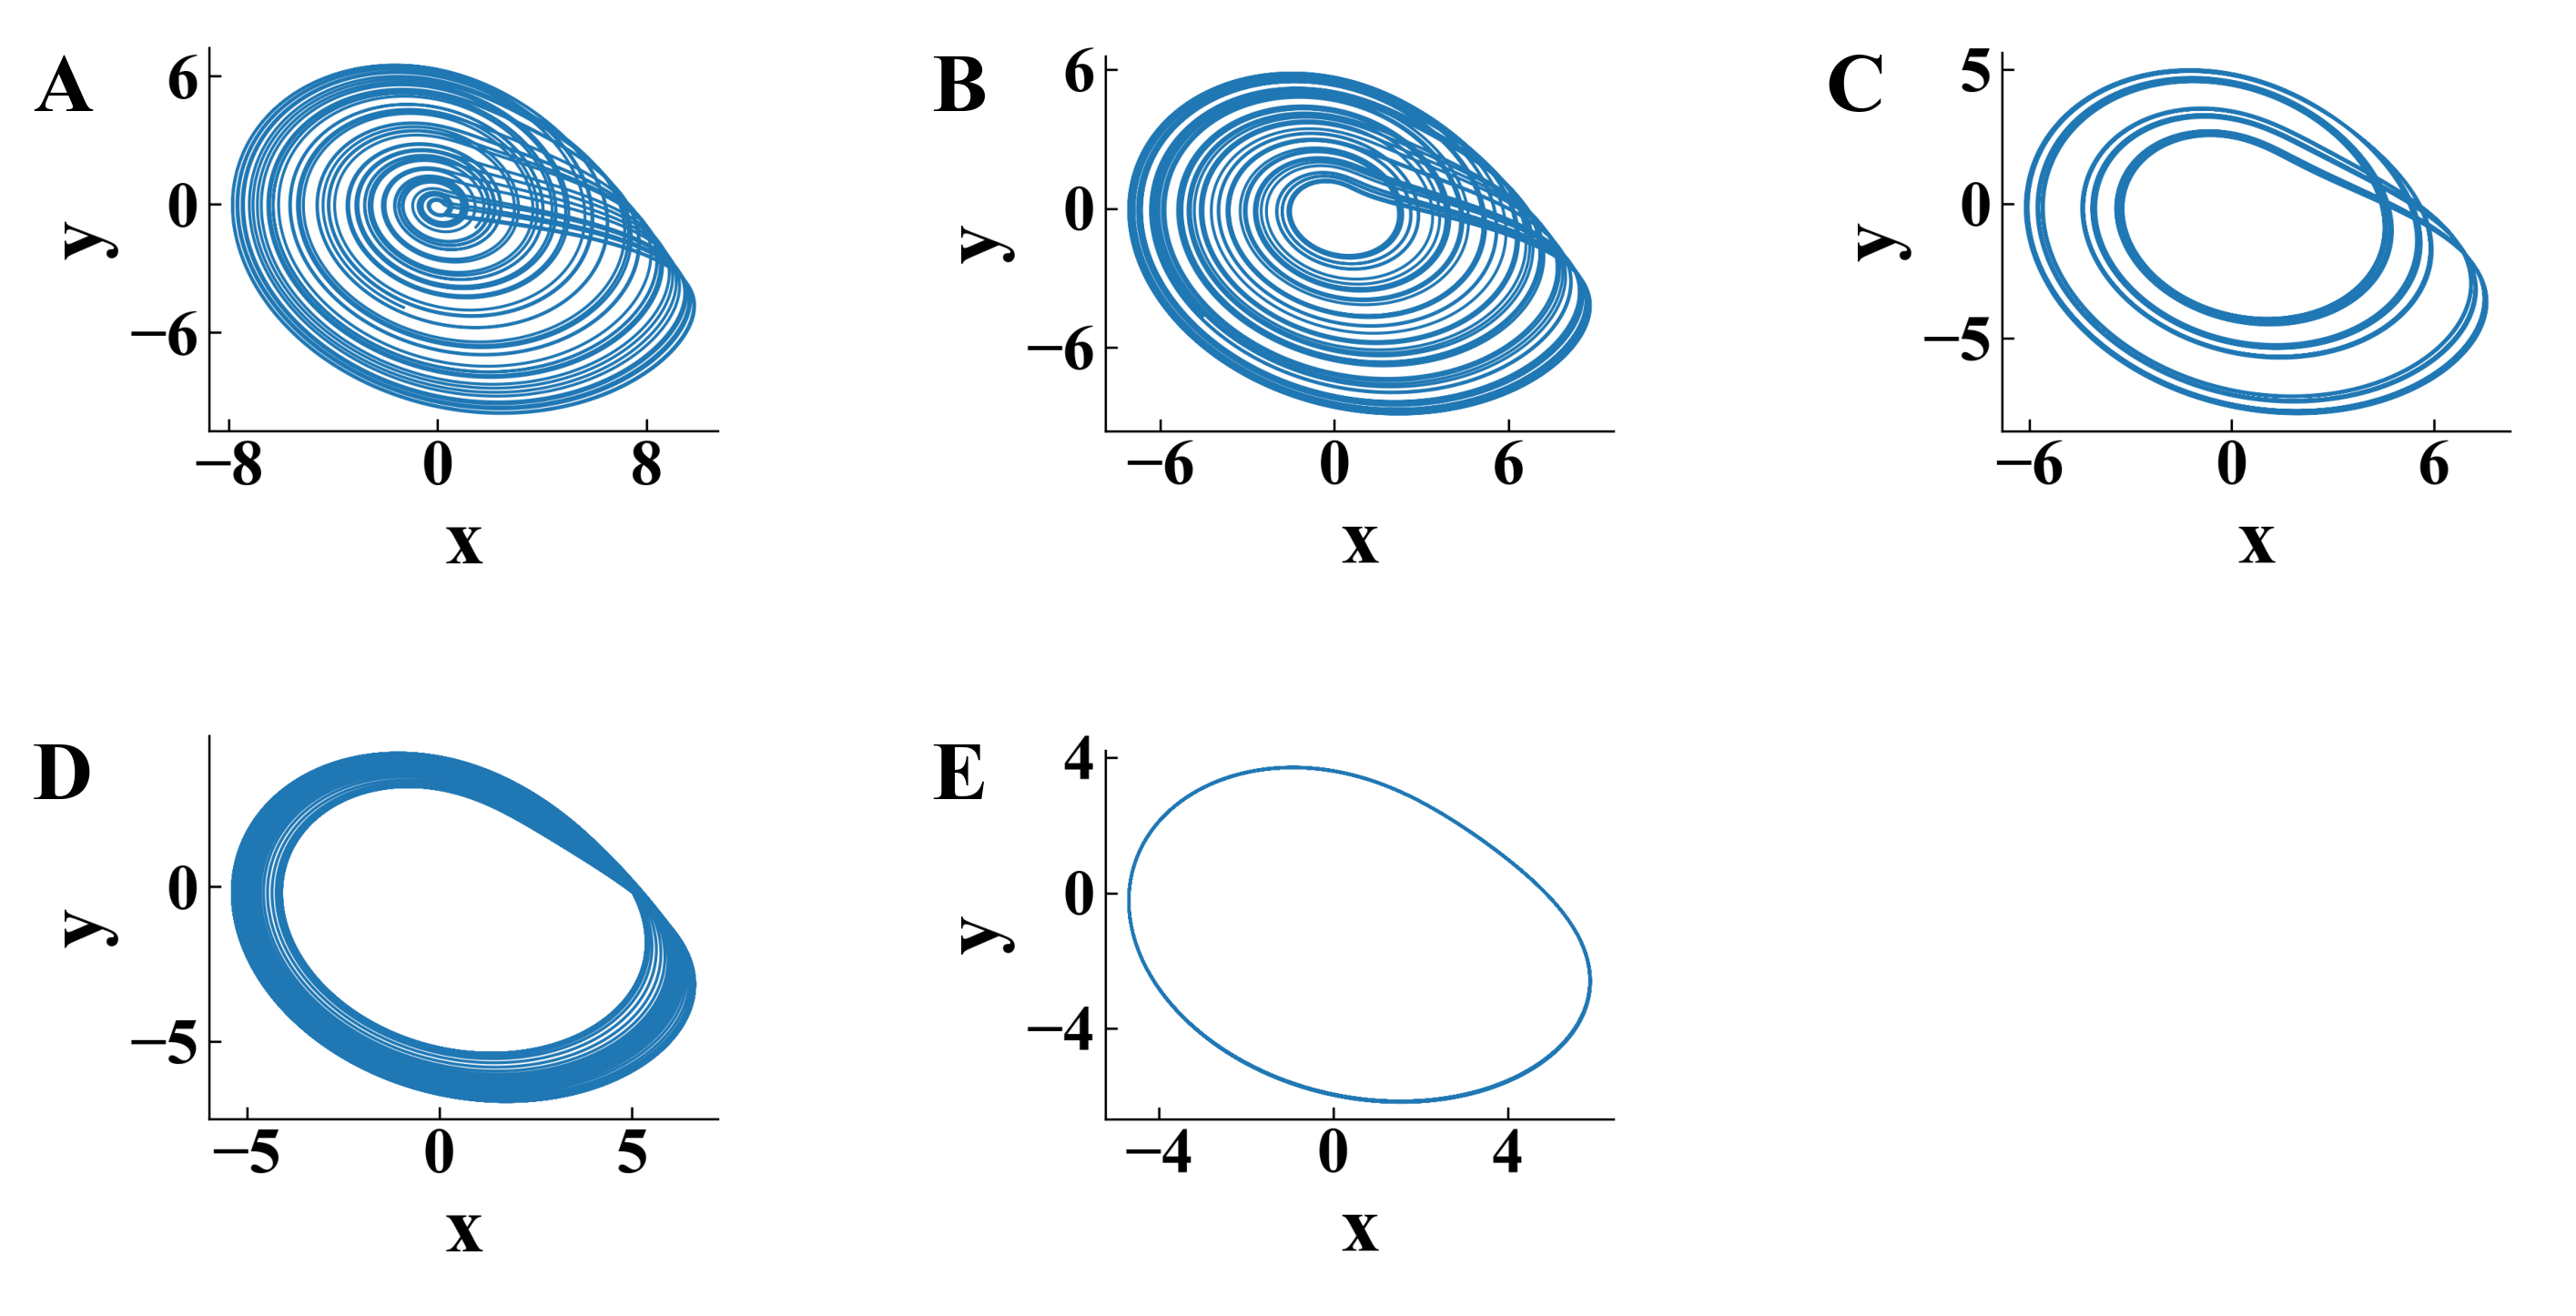

In [5]:
# List of image filenames
image_I_ext = ['PLOTS_ROSSLER_DYNAMICS/I_ext_phase_plot_0.25.png',
               'PLOTS_ROSSLER_DYNAMICS/I_ext_phase_plot_0.5.png',
               'PLOTS_ROSSLER_DYNAMICS/I_ext_phase_plot_1.0.png',
               'PLOTS_ROSSLER_DYNAMICS/I_ext_phase_plot_1.5.png',
               'PLOTS_ROSSLER_DYNAMICS/I_ext_phase_plot_1.75.png'
]


fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 3)

labels = ['A', 'B', 'C', 'D', 'E']

# First row: 3 images
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    img = Image.open(image_I_ext[i])
    ax.imshow(img)
    ax.axis('off')
    ax.text(0.05, 0.95, labels[i], transform=ax.transAxes, fontsize=22, fontweight='bold', color='black', ha='center', va='top')

# Second row: 2 images, last subplot empty
for i in range(3, 5):
    ax = fig.add_subplot(gs[1, i - 3])
    img = Image.open(image_I_ext[i])
    ax.imshow(img)
    ax.axis('off')
    ax.text(0.05, 0.95, labels[i], transform=ax.transAxes, fontsize=22, fontweight='bold', color='black', ha='center', va='top')

# Last subplot (bottom right) left empty
ax_empty = fig.add_subplot(gs[1, 2])
ax_empty.axis('off')

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=0, wspace=0)



folder_name = 'PLOTS_ROSSLER_DYNAMICS'
if save_fig:
    plt.savefig(
        f'{folder_name}/Phase_plot_I_ext.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/Phase_plot_I_ext.svg',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/Phase_plot_I_ext.eps',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/Phase_plot_I_ext.pdf',
        dpi=300,
        bbox_inches='tight'
    )

plt.show()

/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_11631/1739976726.py:34: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=0, wspace=0)
/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_11631/1739976726.py:38: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(
/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_11631/1739976726.py:43: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(
/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/ipykernel_11631/1739976726.py:48: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(
/var/folders/9v/hs9qlpdx4791kpqgpt09stch0000gn/T/i

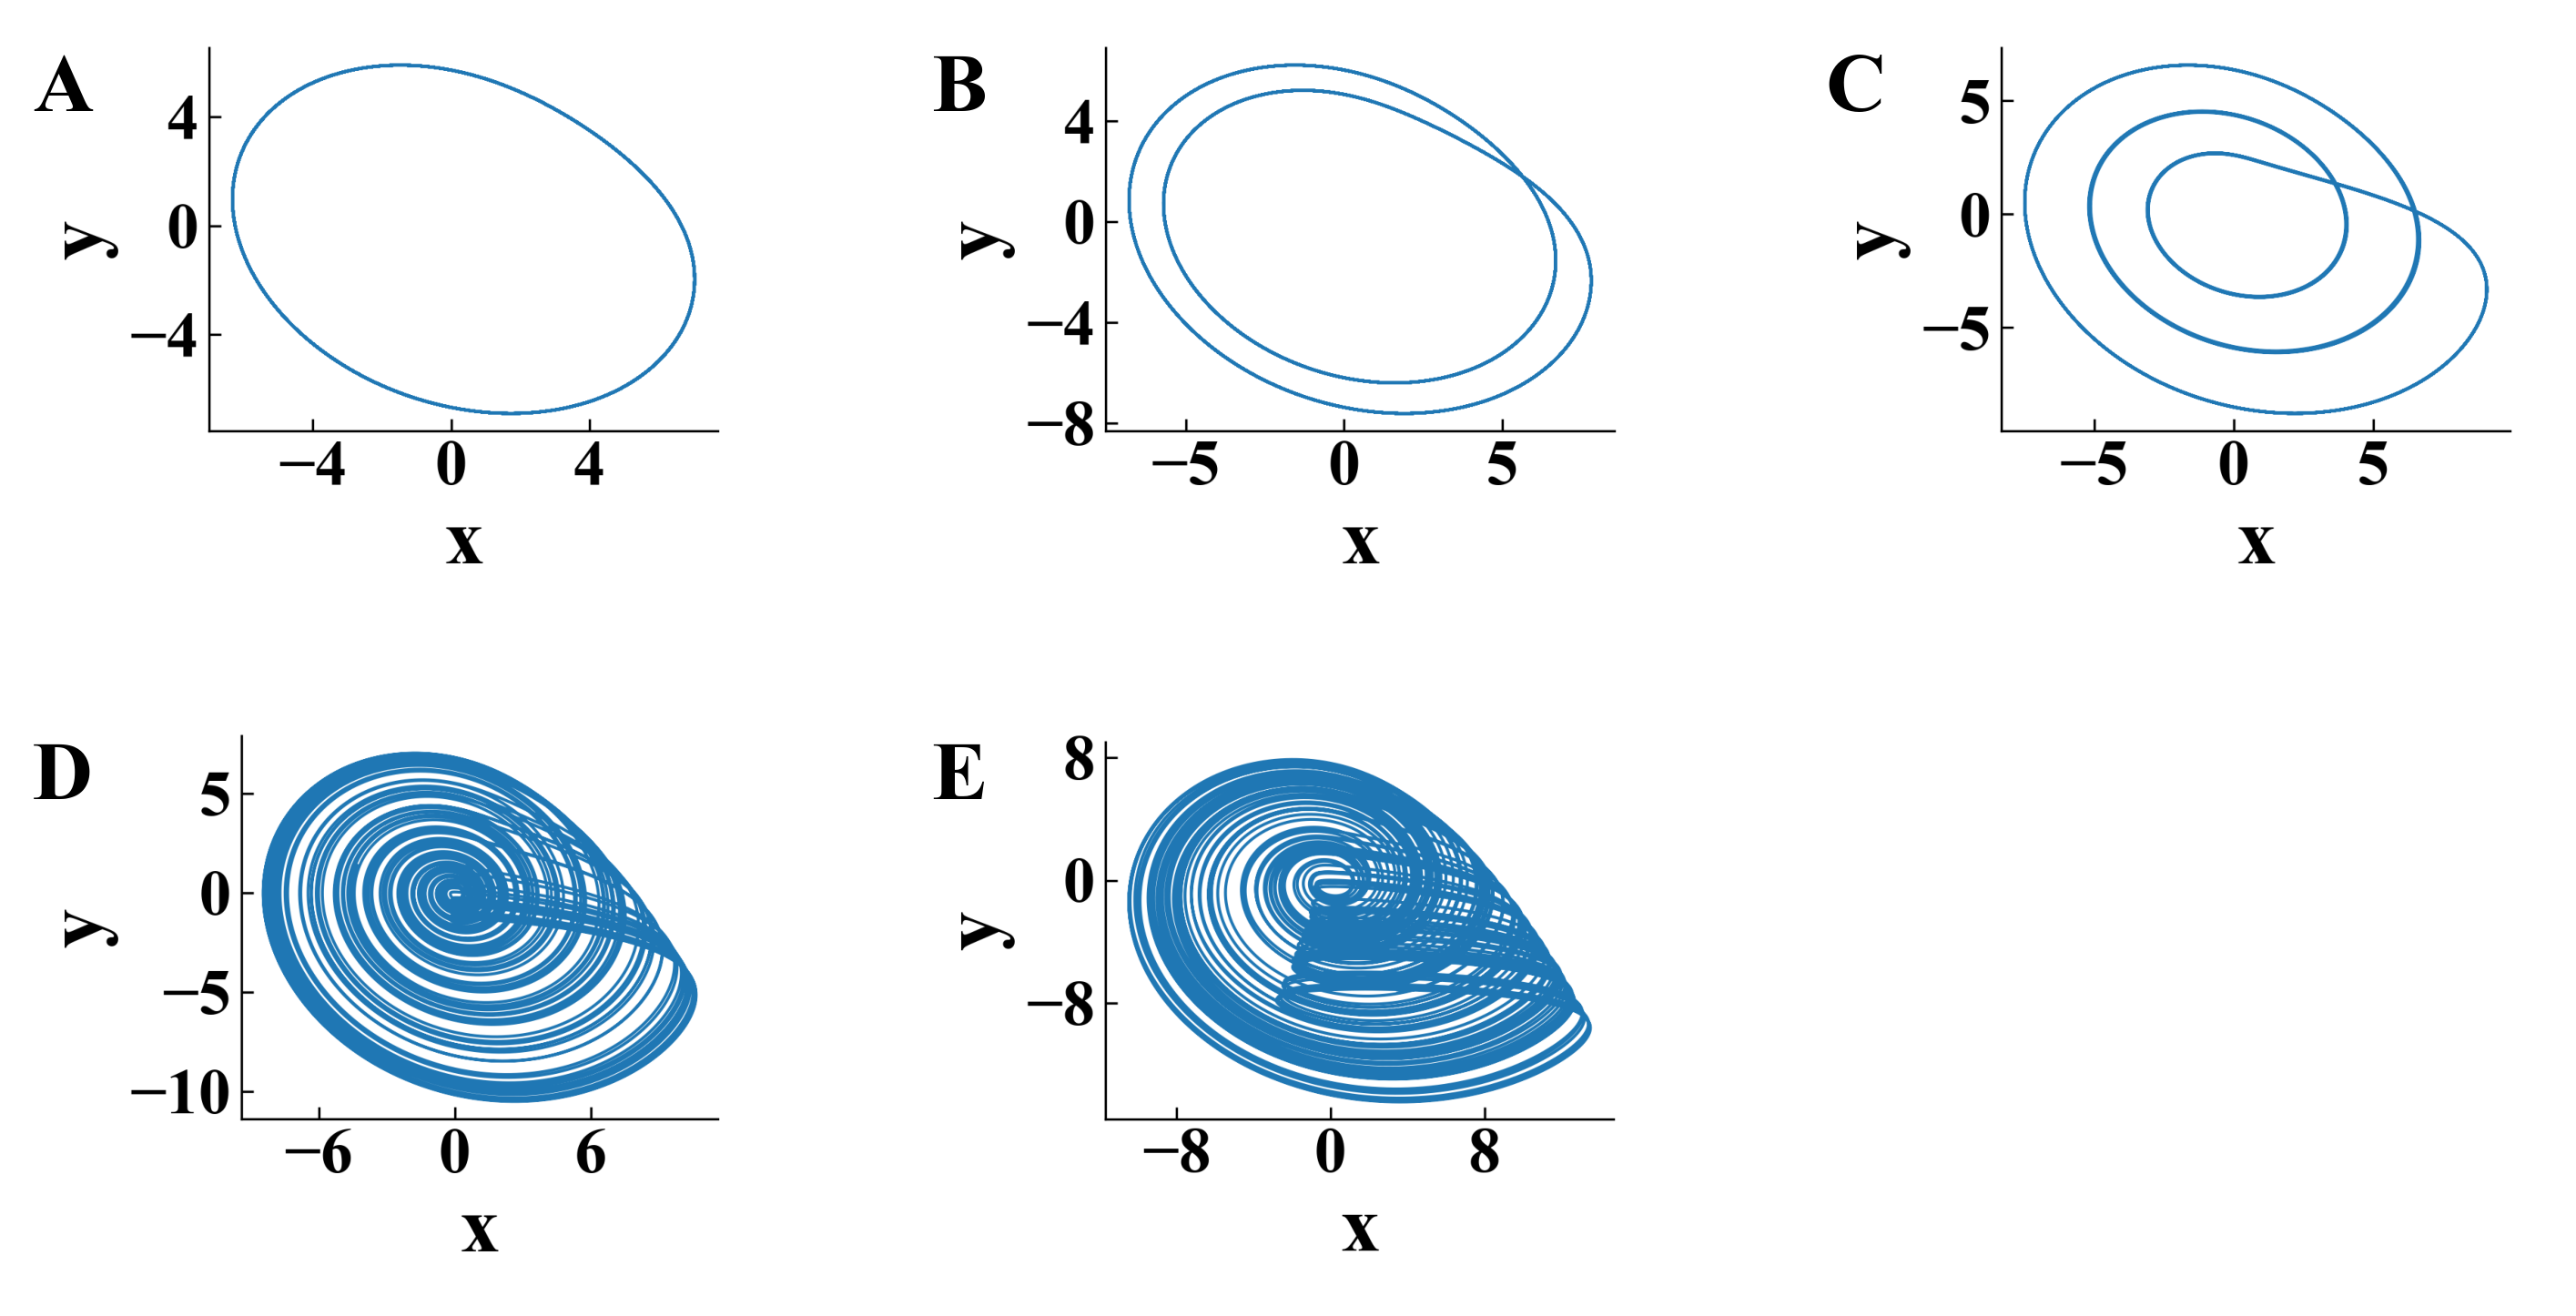

In [7]:


image_k = ['PLOTS_ROSSLER_DYNAMICS/k_phase_plot_0.275.png',
           'PLOTS_ROSSLER_DYNAMICS/k_phase_plot_0.33.png',
           'PLOTS_ROSSLER_DYNAMICS/k_phase_plot_0.43.png',
           'PLOTS_ROSSLER_DYNAMICS/k_phase_plot_0.5.png',
           'PLOTS_ROSSLER_DYNAMICS/k_phase_plot_0.6.png',
           ]


fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 3)

labels = ['A', 'B', 'C', 'D', 'E']

# First row: 3 images
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    img = Image.open(image_k[i])
    ax.imshow(img)
    ax.axis('off')
    ax.text(0.05, 0.95, labels[i], transform=ax.transAxes, fontsize=22, fontweight='bold', color='black', ha='center', va='top')

# Second row: 2 images, last subplot empty
for i in range(3, 5):
    ax = fig.add_subplot(gs[1, i - 3])
    img = Image.open(image_k[i])
    ax.imshow(img)
    ax.axis('off')
    ax.text(0.05, 0.95, labels[i], transform=ax.transAxes, fontsize=22, fontweight='bold', color='black', ha='center', va='top')

# Last subplot (bottom right) left empty
ax_empty = fig.add_subplot(gs[1, 2])
ax_empty.axis('off')

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, hspace=0, wspace=0)

folder_name = 'PLOTS_ROSSLER_DYNAMICS'
if save_fig:
    plt.savefig(
        f'{folder_name}/Phase_plot_k.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/Phase_plot_k.svg',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/Phase_plot_k.eps',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/Phase_plot_k.pdf',
        dpi=300,
        bbox_inches='tight'
    )
    
plt.show()